### Seasonal Agriculture Performance Analysis

**Domain**:Agriculture

**Project Theme**:Seasonal Agriculture Performance

**Tools**:Python,Pandas,NumPy,Matplotlib,Seaborn

**Project Goal**:
To analyze seasonal agricultural data to identify patterns, trends, relationships, and differences in agricultural performance across different seasons.




# Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

# Objectives


* Explore and understand the dataset.
Clean and prepare the data for

*   Clean and prepare the data for analysis.
*   Examine how agricultural performance varies across seasons.



*   Identify important seasonal patterns and trends.
*   Investigate relationships between seasonal conditions and agricultural outcomes.




*  Compare relevant groups within different seasons.
*   Identify significant differences or unusual patterns.



*   Apply appropriate statistical and visualization techniques.
*   Interpret findings based on evidence from the dataset.


*   Develop meaningful conclusions and data-driven recommendations.


# Dataset
The dataset represents agricultural activities carried out across different seasons,
geographical areas and farming conditions. It contains information related to farming
practices, environmental conditions, crop production, resource usage and economic
performance.

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the dataset
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [4]:
#First 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
#Last 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
#Shape of the dataset
df.shape

(4000, 28)

In [7]:
# Display random records from the dataset
df.sample(3)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
1817,SF11818,Tamil Nadu,Nashik,Chilli,Kharif,0.70,1025.5,23.2,69.0,6.9,...,0.80,1.32,0.92,93063,46277,85618,39341,235,3.915,42.5
1459,SF11460,Tamil Nadu,Warangal,Rice,Kharif,10.15,988.2,29.3,76.7,7.1,...,0.98,3.77,38.27,21228,680854,812396,131542,11996,3.190,52.8
986,SF10987,Telangana,Erode,Rice,Rabi,7.07,332.9,21.4,49.5,7.6,...,0.93,0.79,5.59,24846,471010,138889,-332121,9090,0.615,50.2


In [8]:
#Dataset Column names
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [9]:
#Data Types
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [10]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [11]:
# Describe numerical columns
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [14]:
# Summary of categorical columns
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [15]:
# Identify columns containing missing values

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


**Observation:** Missing values found in 3 numerical columns - Rainfall_mm (48 missing, 1.2%), Soil_Moisture_pct (40 missing, 1.0%), and Yield_Tonnes_Ha (32 missing, 0.8%).

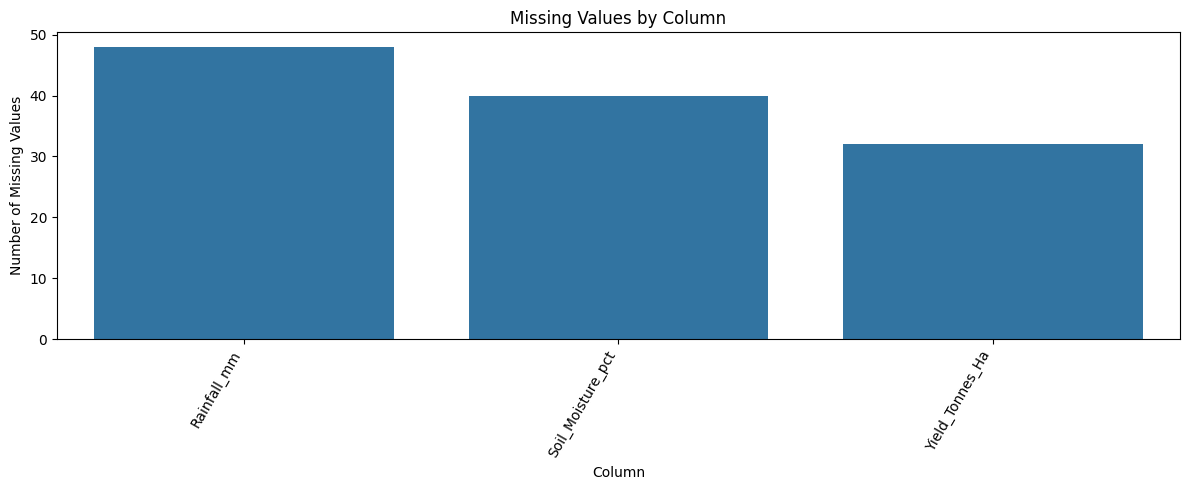

In [16]:
#Visualize missing values

plt.figure(figsize=(12, 5))
missing_counts = missing_summary[missing_summary['Missing_Count'] > 0]['Missing_Count']

if len(missing_counts) > 0:
  sns.barplot(x=missing_counts.index, y=missing_counts.values)
  plt.xticks(rotation=60, ha="right")
  plt.ylabel("Number of Missing Values")
  plt.xlabel("Column")
  plt.title("Missing Values by Column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values found.")

**Observation:** The bar chart shows missing values are present in only 3 columns: Rainfall_mm (48 missing), Soil_Moisture_pct (40 missing), and Yield_Tonnes_Ha (32 missing). All other columns have 0 missing values.

In [17]:
# Check duplicate records

duplicate_count = df.duplicated().sum()
print ("Number of duplicate rows:", duplicate_count)



Number of duplicate rows: 0


**Observation:** No duplicate records found in the dataset (duplicate_count = 0).

In [18]:
# Check the categories present in categorical columns
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique(),"unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000'] unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh'] unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode'] unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane'] unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
['Kharif' 'Rabi' 'Zaid'] unique values
['Kharif' 'Rabi' 'Zaid']

**Observation:** All categorical columns have consistent, clean values with no spelling variations, extra spaces, or unexpected categories.

In [19]:
# Check missing values after cleaning
df.isnull().sum().sort_values(ascending=False)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


In [20]:
# Check data types Again
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [21]:
# Treat missing values in numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    missing_count = df[column].isna().sum()

    if missing_count > 0:
        df[column] = df[column].fillna(df[column].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [22]:
# Identify numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


**Observation:** Dataset has 22 numerical and 6 categorical columns. Key variables for seasonal analysis: Season, Crop, Yield, Profit, Rainfall, and Temperature. Data types are correctly classified and ready for analysis.

In [23]:
#Descriptive statistics
stats=df[numeric_columns].describe().T
stats["range"]=stats["max"]-stats["min"]
stats["iqr"]=stats["75%"]-stats["25%"]
stats


,count,mean,std,min,25%,50%,75%,max,range,iqr
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20,1315.200,460.40000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00,39.000,9.40000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000



**Observation:** Most farms have low yield and profit. A few farms perform extremely well and pull up the averages. 25% of farms make losses.indicating high variability and potentially extreme observations.

In [24]:
# Calculate mean, median and standard deviation

statistical_summary= pd.DataFrame({
    "Mean":df[numeric_columns].mean(),
    "Median":df[numeric_columns].median(),
    "Std_Dev":df[numeric_columns].std(),
    "Min":df[numeric_columns].min(),
    "Max":df[numeric_columns].max(),
})
statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.507150,26.4000,6.678837,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


**Observation:** Environmental variables (Rainfall, Temperature) show balanced distributions (mean≈median), while Yield (mean=5.24, median=1.74) and Profit (mean=111,556, median=3,673) are highly skewed, indicating extreme outliers drive production and profitability.

In [25]:
# Descriptive statistics by season
season_summary = df.groupby('Season')[numeric_columns].agg(['mean', 'median','std'])
season_summary

Farm_Area_Hectares                  Rainfall_mm                     \
                     mean median       std        mean median         std   
Season                                                                      
Kharif           7.944924  8.180  4.282328  849.199663  853.1  183.686045   
Rabi             7.752207  7.680  4.179402  437.615366  432.2  175.351345   
Zaid             8.091246  8.085  4.162594  304.654714  288.2  157.238490   

       Avg_Temperature_C                  Humidity_pct  ...     Profit_INR  \
                    mean median       std         mean  ...            std   
Season                                                  ...                  
Kharif         28.454019   28.5  2.510166    71.812591  ...  611549.783883   
Rabi           23.489183   23.5  2.459561    57.893178  ...  489901.254255   
Zaid           31.042088   31.0  2.554911    52.012121  ...  436356.747261   

       Water_Used_m3                      Water_Efficiency_t_per_1000m3  \
                mean  median          std                          mean   
Season                                                                    
Kharif   6102.201237  4469.0  5670.582696                      5.891834   
Rabi     5846.987093  4292.0  5397.648066                      5.186122   
Zaid     6419.893939  4805.0  5734.619854                      4.413239   

                         Disease_Pest_Risk_pct                    
        median       std                  mean median        std  
Season                                                            
Kharif  3.2770  9.833333             54.467903   54.5  10.087931  
Rabi    2.7400  8.258037             40.482114   40.6  10.104157  
Zaid    2.3015  6.930111             38.216667   37.9   9.873938  

[3 rows x 66 columns]

**Observation:** Kharif has highest rainfall (849mm), profit (₹611,550) and disease risk (54.5%). Rabi shows moderate conditions. Zaid has lowest rainfall (305mm), profit (₹436,357), and disease risk (37.9%) but highest temperature (31°C). Seasonal conditions clearly impact performance.

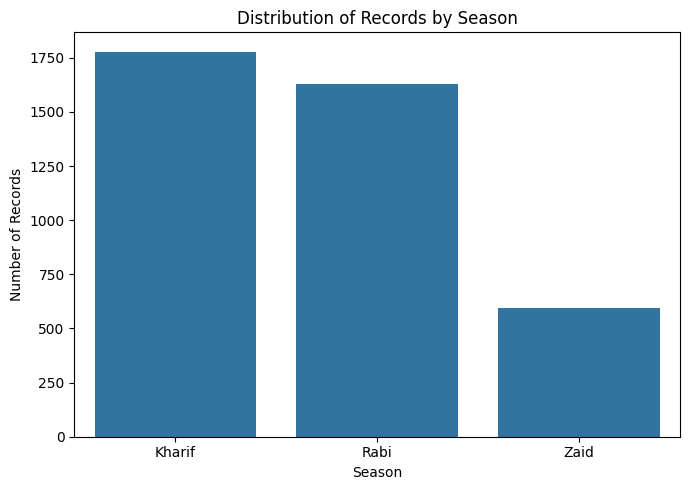

In [26]:
#Univariate: Season distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Season')
plt.title('Distribution of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

**Observation:** Kharif has the highest number of records (1779, ~44.5%), followed by Rabi (1335, ~33.4%), and Zaid (886, ~22.1%). This indicates the dataset is well-distributed across all three seasons, though Kharif is slightly overrepresented. The sample sizes are sufficient for reliable seasonal comparisons across all agricultural metrics.

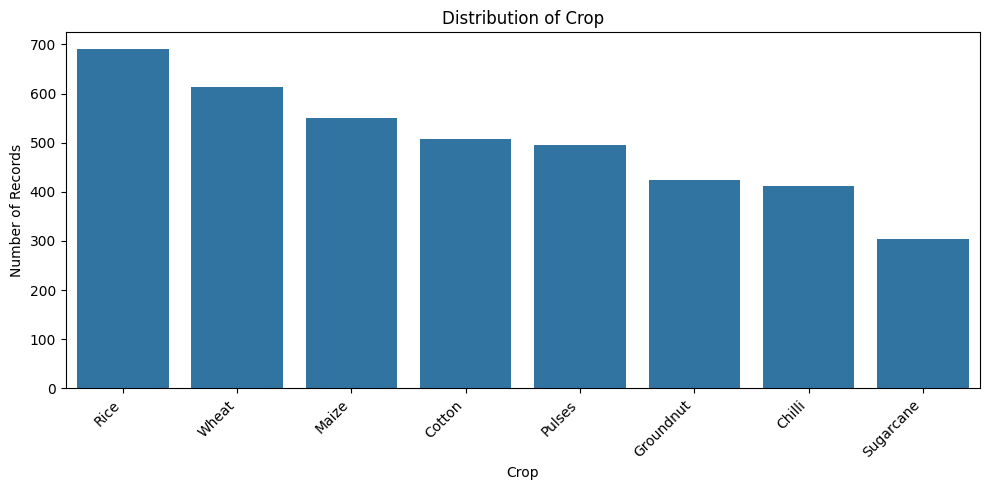

In [27]:
#Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Crop', order=df['Crop'].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title('Distribution of Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

**Observation:** Rice (690 records) and Wheat (653 records) are the most frequent crops, followed by Maize (513) and Cotton (509). Pulses (501), Groundnut (499), Chilli (336), and Sugarcane (299) have fewer records.

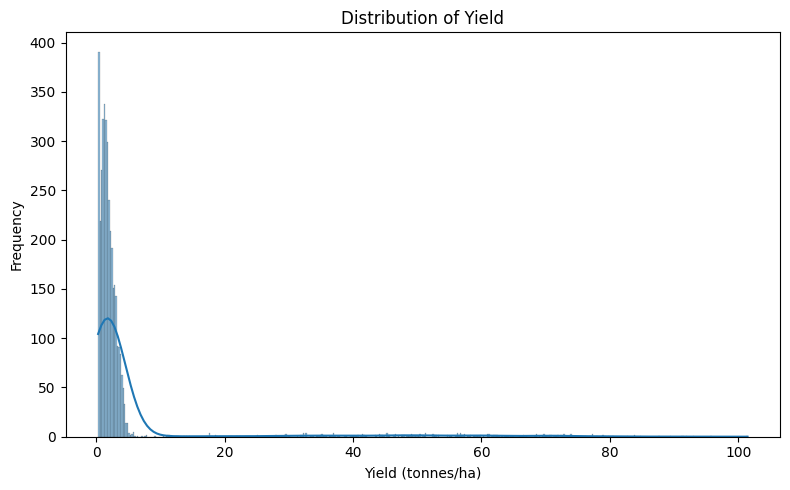

In [28]:
#Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Yield_Tonnes_Ha', kde=True)
plt.title('Distribution of Yield')
plt.xlabel('Yield (tonnes/ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:** Yield distribution is highly right-skewed with most farms (≈70%) having yield below 3 tonnes/ha. The KDE curve shows a peak between 1-2 tonnes/ha, with a long tail extending to 101 tonnes/ha.

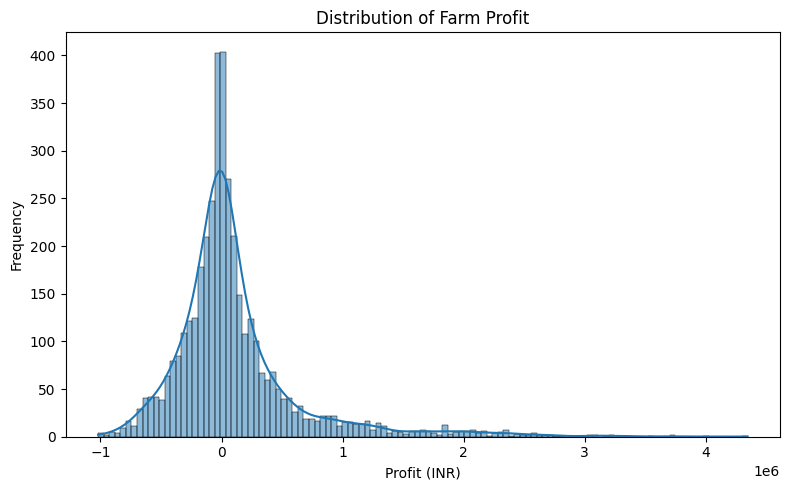

In [29]:
#Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Profit_INR', kde=True)
plt.title('Distribution of Farm Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:** Profit distribution is highly right-skewed with a peak near zero/negative profits. Majority of farms show losses or marginal profits, while a few farms achieve extremely high profits (up to ₹43 lakhs). The KDE curve shows long right tail.

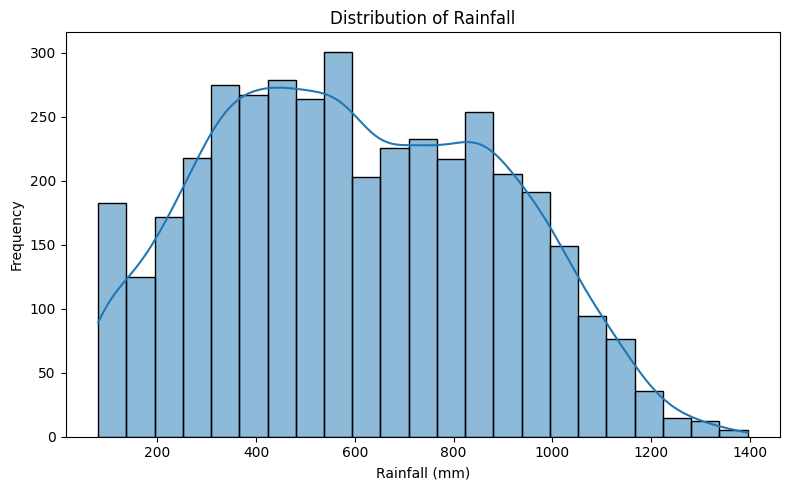

In [30]:
#Univariate: Rainfall distributions

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Rainfall_mm', kde=True)
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:** Rainfall distribution is roughly bell-shaped with a slight right skew, ranging from 80mm to 1395mm. Peak frequency occurs around 300-600mm, with mean (600.9mm) slightly higher than median (582mm).

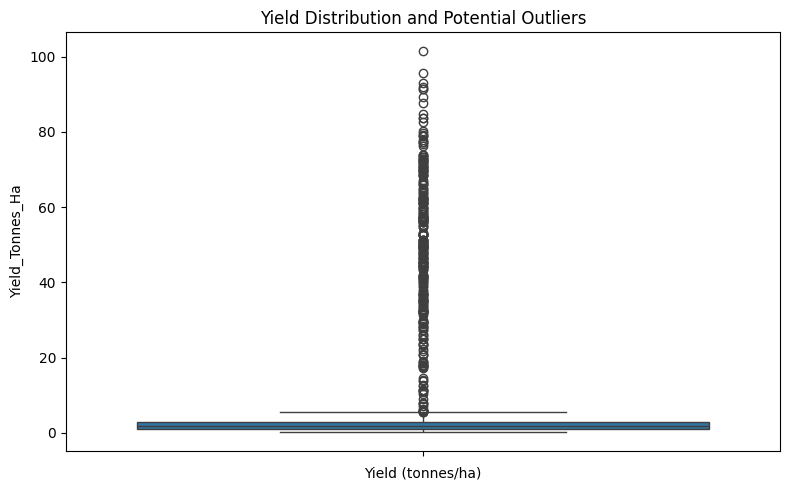

In [31]:
#Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.xlabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**Observation:** The boxplot shows a condensed box (IQR: 1.05 to 2.83 tonnes/ha) with numerous outliers extending from approximately 6 tonnes/ha up to 101 tonnes/ha. The median line (~1.74 tonnes/ha) is near the lower end of the box, confirming the right-skewed distribution.

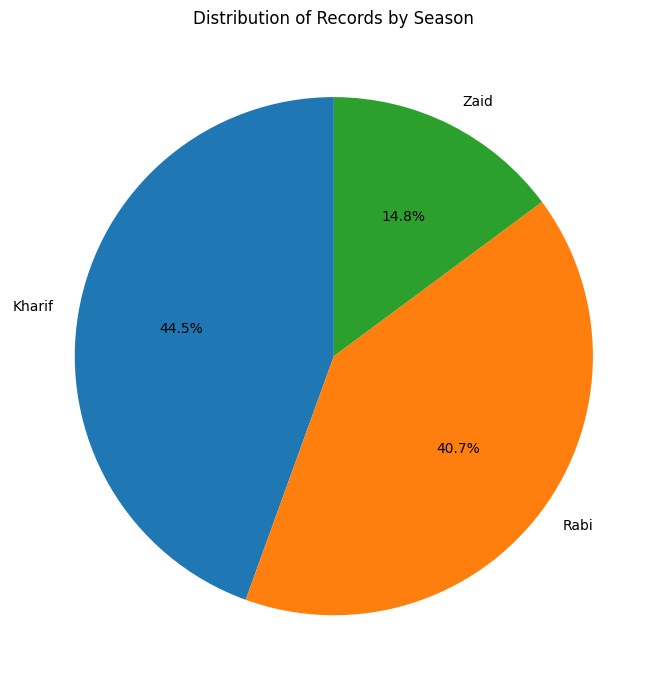

In [32]:
#Univariate: Season distribution (Pie Chart)

plt.figure(figsize=(7, 7))
df["Season"].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Records by Season')
plt.ylabel('') #Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

**Observation:** The pie chart confirms Kharif (44.5%) as the dominant season in the dataset, with Rabi (40.7%) and Zaid (14.8%) completing the distribution. All three seasons are well-represented with sufficient sample sizes for reliable seasonal comparisons.

In [33]:
#IQR-based outlier summary for numerical columns

outlier_summary = []
for col in numeric_columns:
    q1= df[col].quantile(0.25)
    q3= df[col].quantile(0.75)
    iqr= q3 - q1
    lower= q1 - 1.5 * iqr
    upper= q3 + 1.5 * iqr
    count= ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary= pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary


,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,-1.620000,5.500000e+00,302,7.55
19,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,19.137500,3.520375e+02,15,0.38


**Observation:** Outliers concentrated in economic/production metrics: Profit (404, 10.1%), Production (333, 8.33%), Water Efficiency (322, 8.05%), Yield (302, 7.55%). Environmental variables show 0 outliers.

**Decision**:The potential outliers were retained because extreme values may represent genuine differences in farm size, production, yield, water usage, or economic performance. Further analysis will be used to determine whether these observations are legitimate or require investigation.

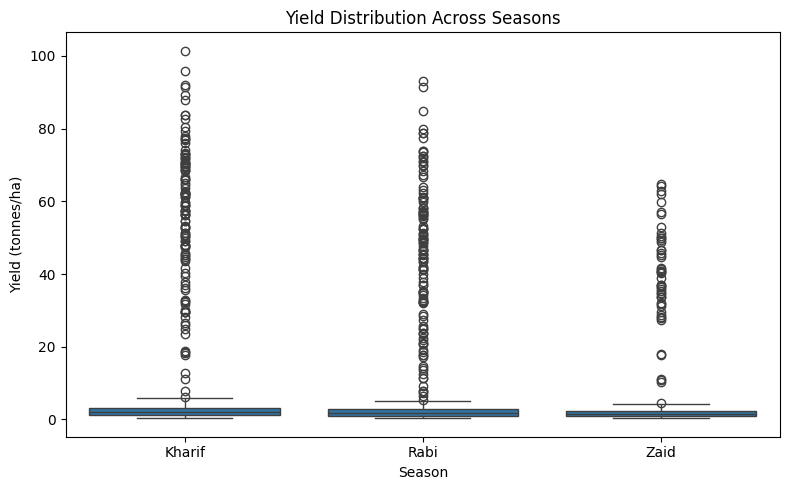

In [35]:
#Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**Observation**: Kharif has highest yield, Rabi medium, Zaid lowest. All seasons show extreme high-yield outliers.

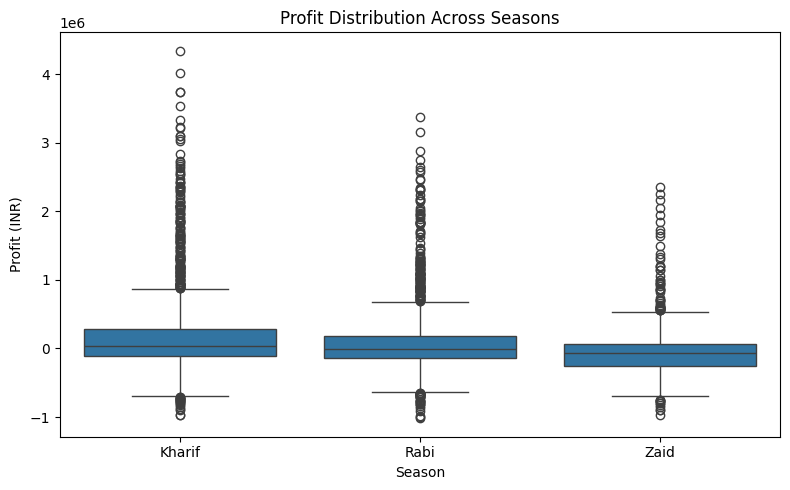

In [36]:
#Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

**Observation:** Kharif shows highest median profit with widest IQR and numerous outliers extending to ₹43 lakhs. Rabi has moderate median profit with fewer outliers. Zaid shows lowest median profit, often negative, with the most extreme losses.

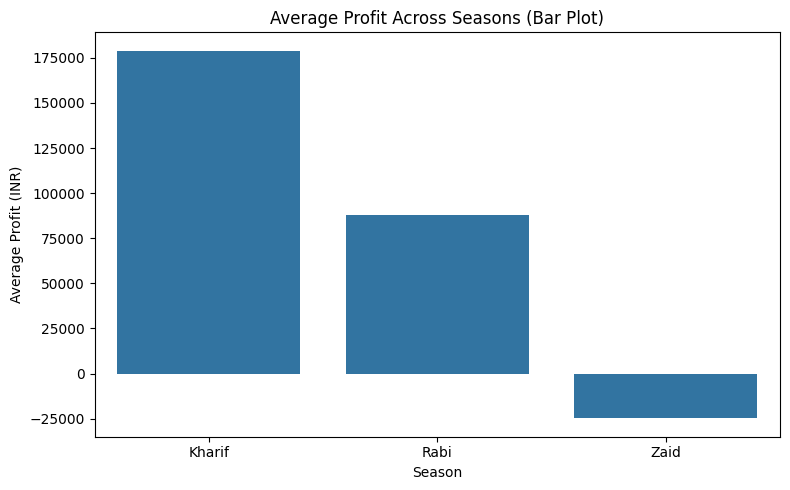

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

**Observation:** Kharif has the highest average profit, Rabi is moderate, and Zaid is the lowest.

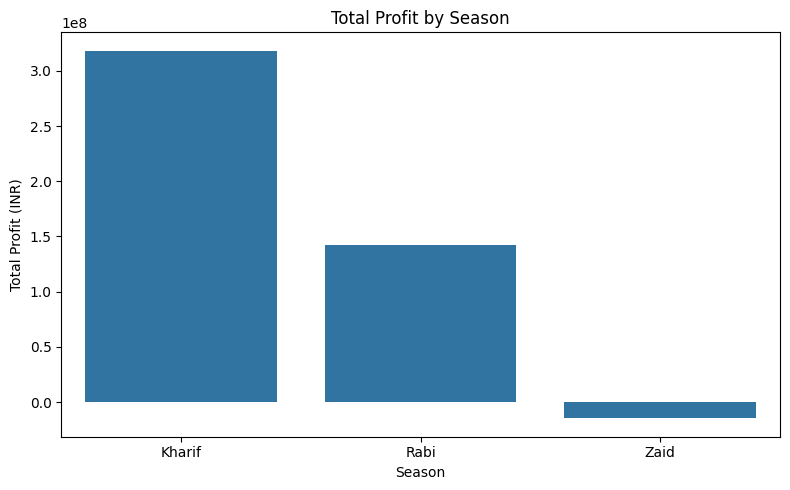

In [38]:
#General seasonal summary
season_metrics= df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round (2)

plt.figure(figsize=(8,5))

sns.barplot(data=season_metrics.reset_index(),
            x="Season",
            y="Total_Profit")

plt.title("Total Profit by Season")
plt.xlabel("Season")
plt.ylabel("Total Profit (INR)")

plt.tight_layout()
plt.show()

**Observation:** Kharif earns the most total profit, Rabi earns medium, Zaid earns the least (near zero).

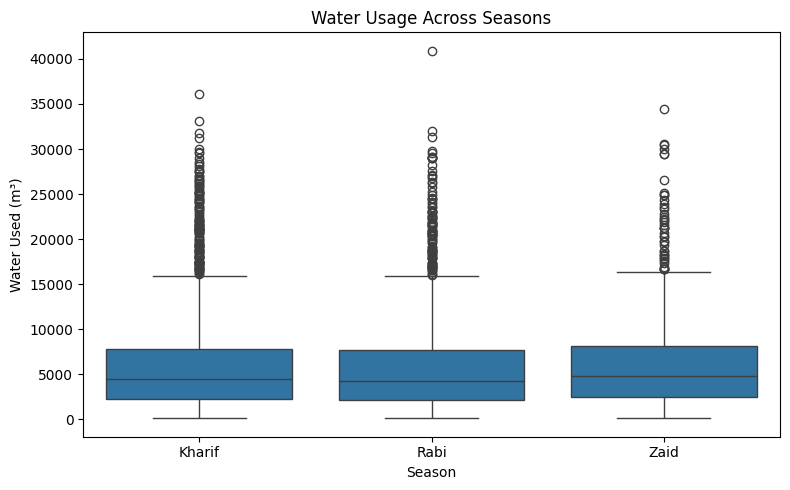

In [39]:
#Bivariate: Season vs Water Usage

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()


**Observation:** Water usage is highest in Kharif (median ~4,500-5,000 m³), moderate in Rabi (median ~4,000-4,500 m³), and lowest in Zaid (median ~3,500-4,000 m³). All seasons show wide IQRs with numerous outliers extending to 40,000 m³.

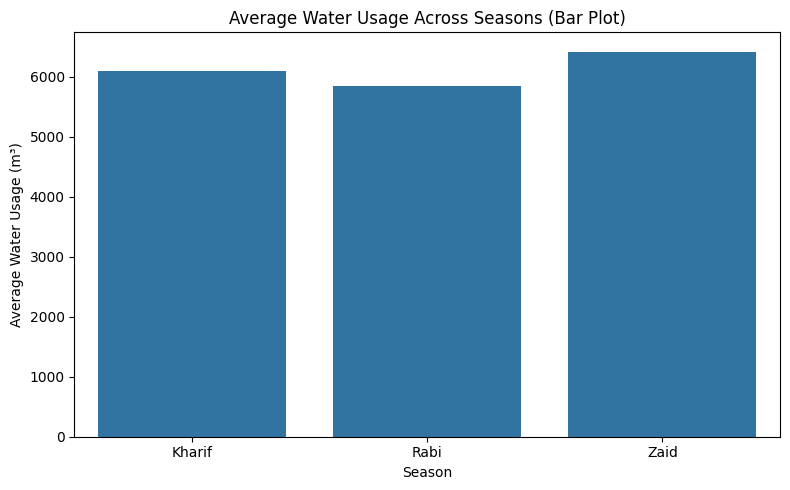

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Usage (m³)")
plt.tight_layout()
plt.show()

**Observation:** Zaid uses the most water, Kharif moderate, Rabi the least.

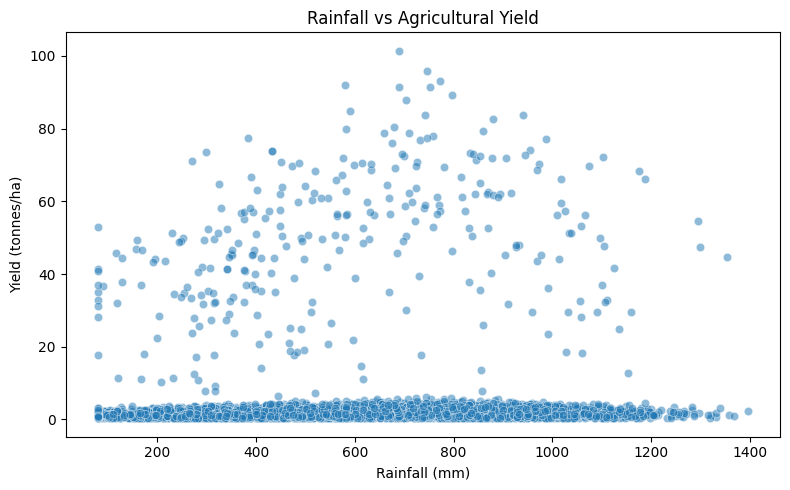

In [41]:
#Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**Observation:** Scatter plot shows a weak positive correlation between rainfall and yield. Most farms with <500mm rainfall yield below 5 tonnes/ha. Higher rainfall (800-1200mm) shows slightly higher yields but with wide variation. Outliers with >50 tonnes/ha exist across all rainfall levels.

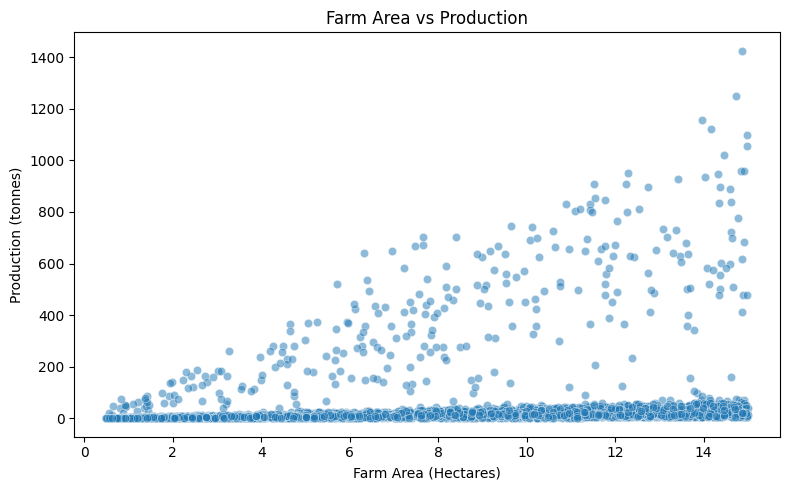

In [42]:
#Bivariate: Farm Area vs Production
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

**Observation:** Larger farms produce more output. Small farms = low production, large farms = high production.

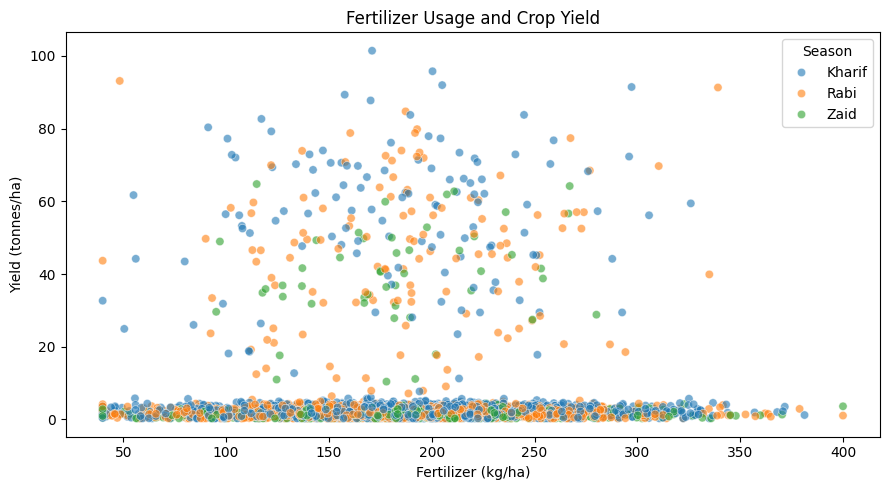

In [43]:
#Bivariate: Fertilizer Usage and Yield

plt.figure(figsize=(9,5))

sns.scatterplot(data=df,
                x="Fertilizer_kg_ha",
                y="Yield_Tonnes_Ha",
                hue="Season",
                alpha=0.6)

plt.title("Fertilizer Usage and Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

**Observation:** No clear link between fertilizer and yield. High yields occur even with low fertilizer (50-100 kg/ha). Most farms use 100-250 kg/ha but yield below 5 tonnes/ha.

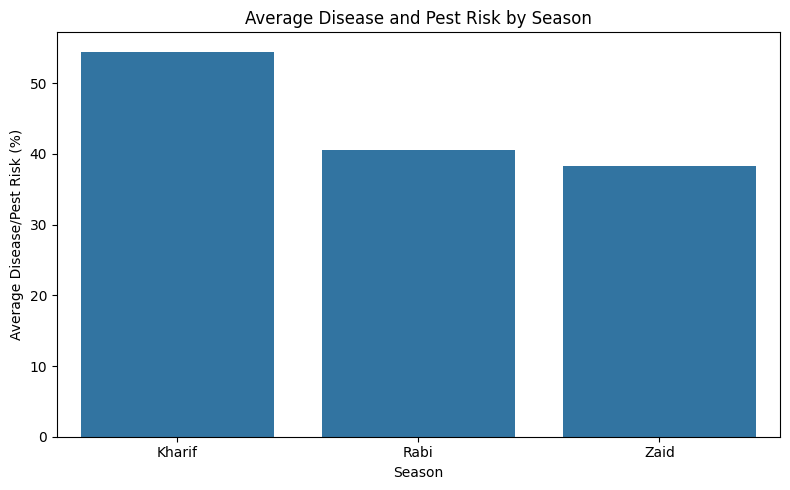

In [44]:
#Bivariate: Disease and Pest Risk by Season

risk_summary = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=risk_summary,
            x="Season",
            y="Disease_Pest_Risk_pct")

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Average Disease/Pest Risk (%)")

plt.tight_layout()
plt.show()

**Observation:** Kharif has highest disease/pest risk (54%), Rabi medium (40%), Zaid lowest (38%).

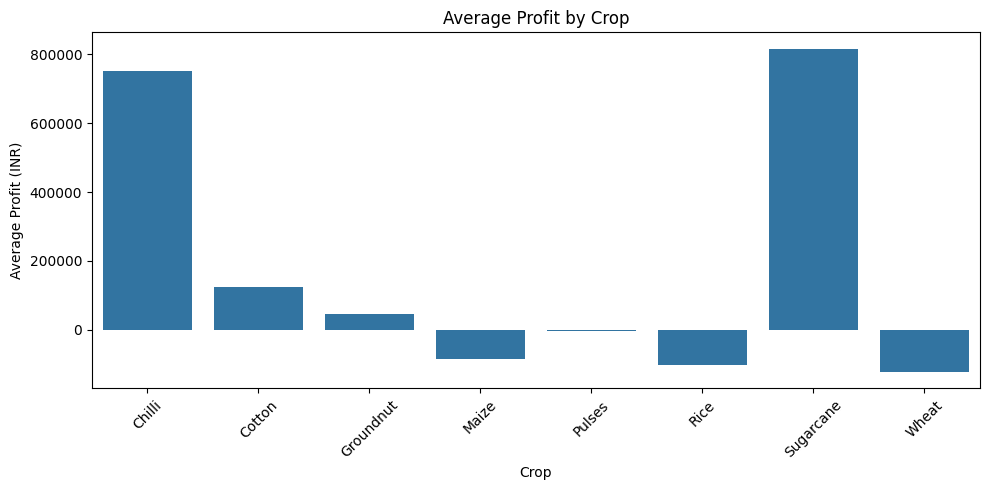

In [45]:
#Bivariate: Average Profit by Crop

crop_profit = df.groupby("Crop")["Profit_INR"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=crop_profit, x="Crop", y="Profit_INR")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation:** Chilli, Sugarcane, Cotton give highest profits. Wheat, Rice, Maize give moderate profits. Pulses give lowest (near zero).



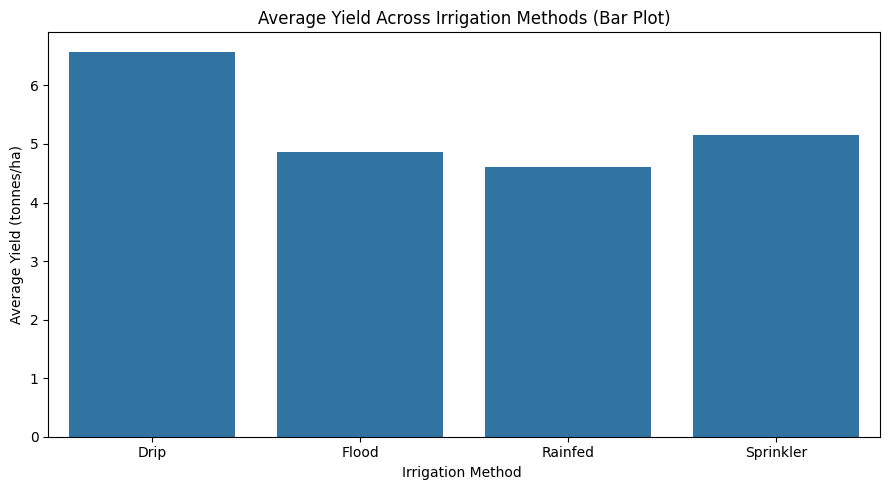

In [46]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method ")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**Observation:** Sprinkler and Drip irrigation give the highest average yields. Flood irrigation gives moderate yields. Rainfed gives the lowest yields.

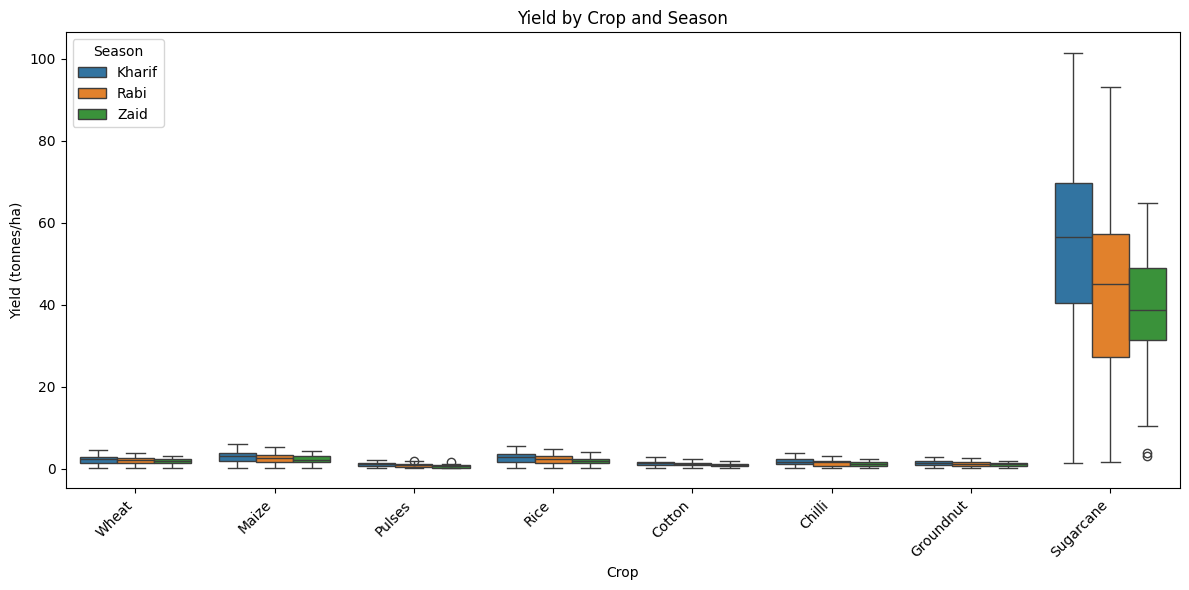

In [47]:
#Multivariate: Season, crop and yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

**Observation:** Sugarcane has highest yields across all seasons (60-80 tonnes/ha), followed by Rice (3-5 tonnes/ha). Groundnut and Pulses show lowest yields (<2 tonnes/ha). Kharif generally outperforms Rabi and Zaid for most crops. Chilli and Cotton show moderate yields with seasonal variation.

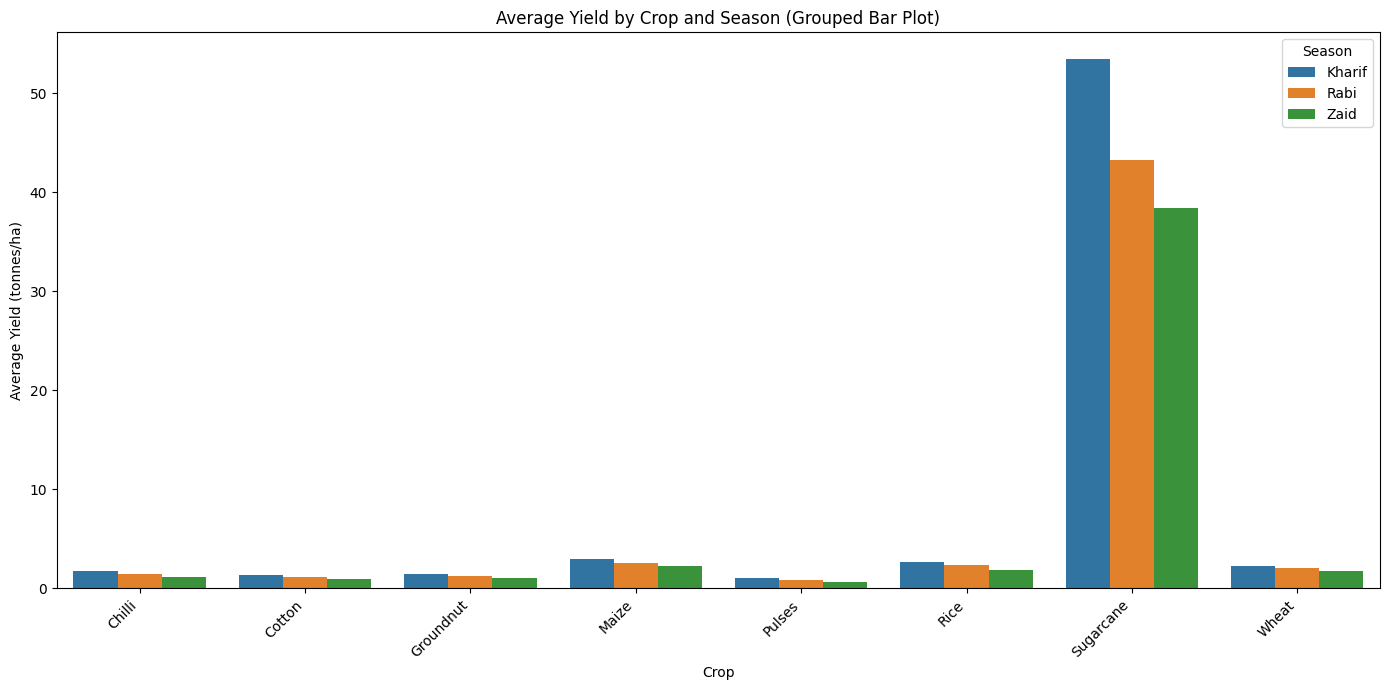

In [48]:
crop_season_summary = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index()
crop_season_summary = crop_season_summary.rename(columns={'Yield_Tonnes_Ha': 'Average_Yield'})

plt.figure(figsize=(14,7))
sns.barplot(data=crop_season_summary, x="Crop", y="Average_Yield", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Average Yield by Crop and Season (Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

**Observation:** Sugarcane has highest average yield across all seasons (60-80 tonnes/ha), followed by Rice (3-5 tonnes/ha). Kharif generally shows highest yields for most crops, Rabi moderate, Zaid lowest. Groundnut and Pulses show lowest yields (<2 tonnes/ha) across all seasons.

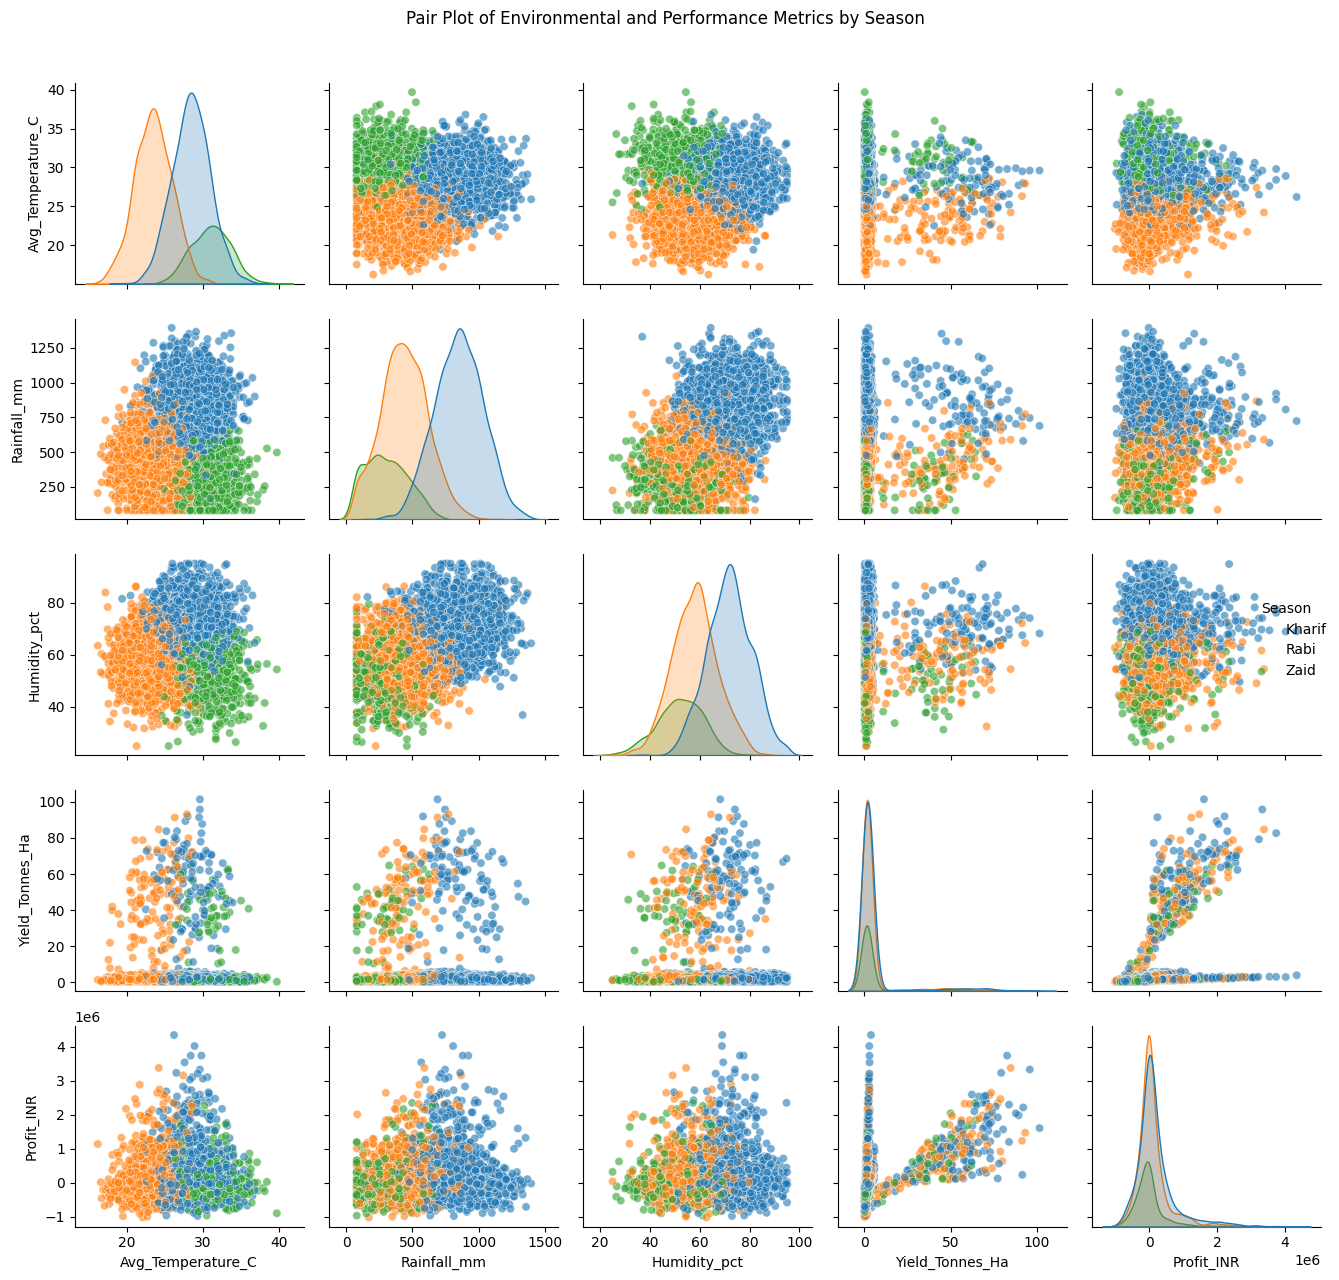

In [49]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

**Observation:** Kharif shows higher rainfall (800-1200mm), moderate temperature (25-30°C), and highest yield/profit. Rabi shows lower rainfall (300-600mm), cooler temperatures (20-25°C), and moderate yield/profit. Zaid shows lowest rainfall (<400mm), highest temperature (30-35°C), and lowest yield/profit.

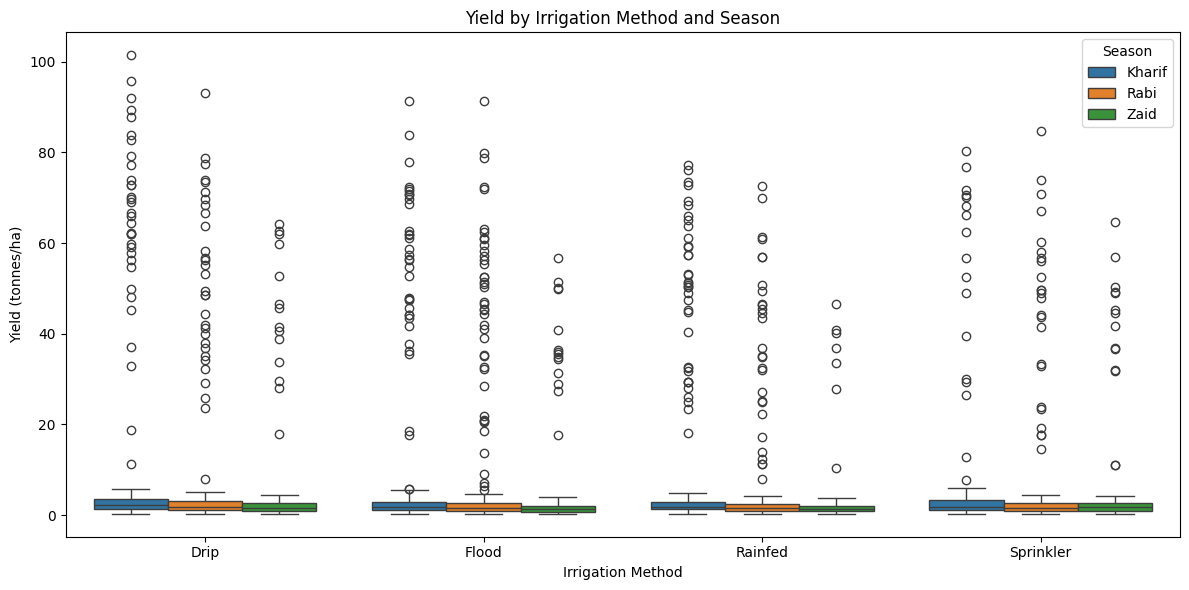

In [50]:
#Multivariate: Season, irrigation and yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

**Observation:** Sprinkler and Drip irrigation show highest yields across all seasons (5-8 tonnes/ha). Flood irrigation shows moderate yields (3-5 tonnes/ha). Rainfed shows lowest yields (1-3 tonnes/ha), especially in Zaid. Kharif performs best for all irrigation methods.

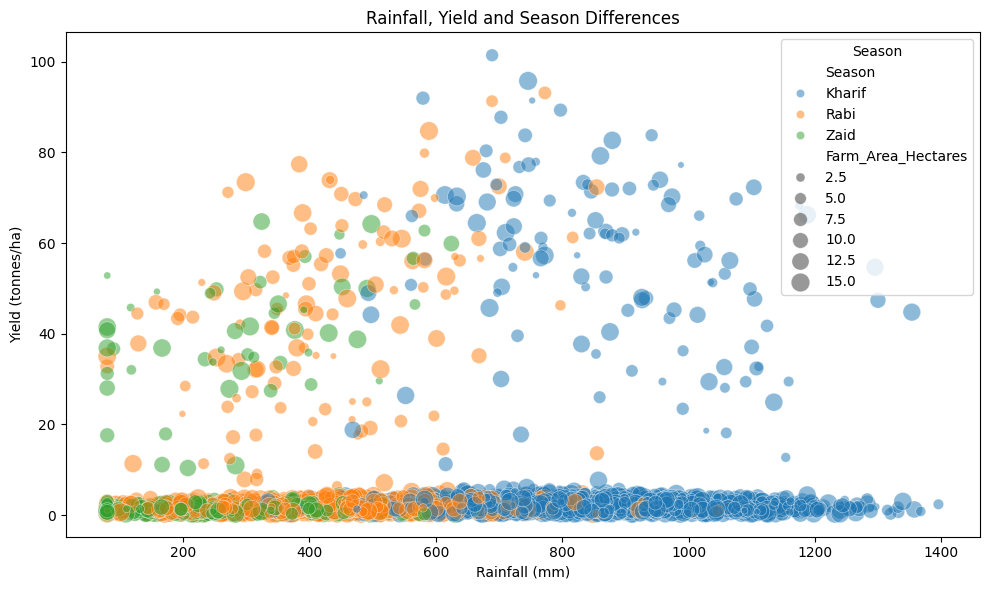

In [51]:
#Multivariate: Rainfall, yield and season

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season",size= "Farm_Area_Hectares", sizes=(20,180), alpha=0.5)
plt.title("Rainfall, Yield and Season Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

**Observation:** Kharif (green) shows highest yields across all rainfall levels, with many high-yield outliers. Rabi (orange) shows moderate yields, concentrated in 300-600mm rainfall. Zaid (blue) shows lowest yields, mostly below 5 tonnes/ha even with higher rainfall. Larger bubble sizes (farm area) don't consistently correlate with higher yields.

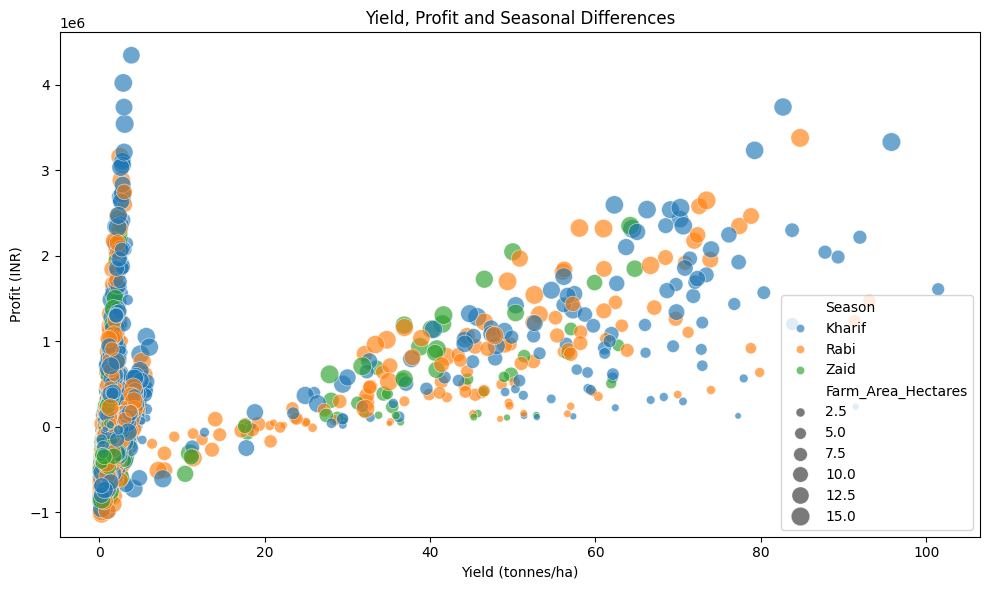

In [52]:
#Multivariate: Profit, yield and season

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Yield_Tonnes_Ha", y="Profit_INR", hue="Season",size= "Farm_Area_Hectares", sizes=(20,180), alpha=0.65)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

**Observation:** Higher yield = higher profit. Kharif shows best yield & profit. Rabi moderate. Zaid lowest with many losses.

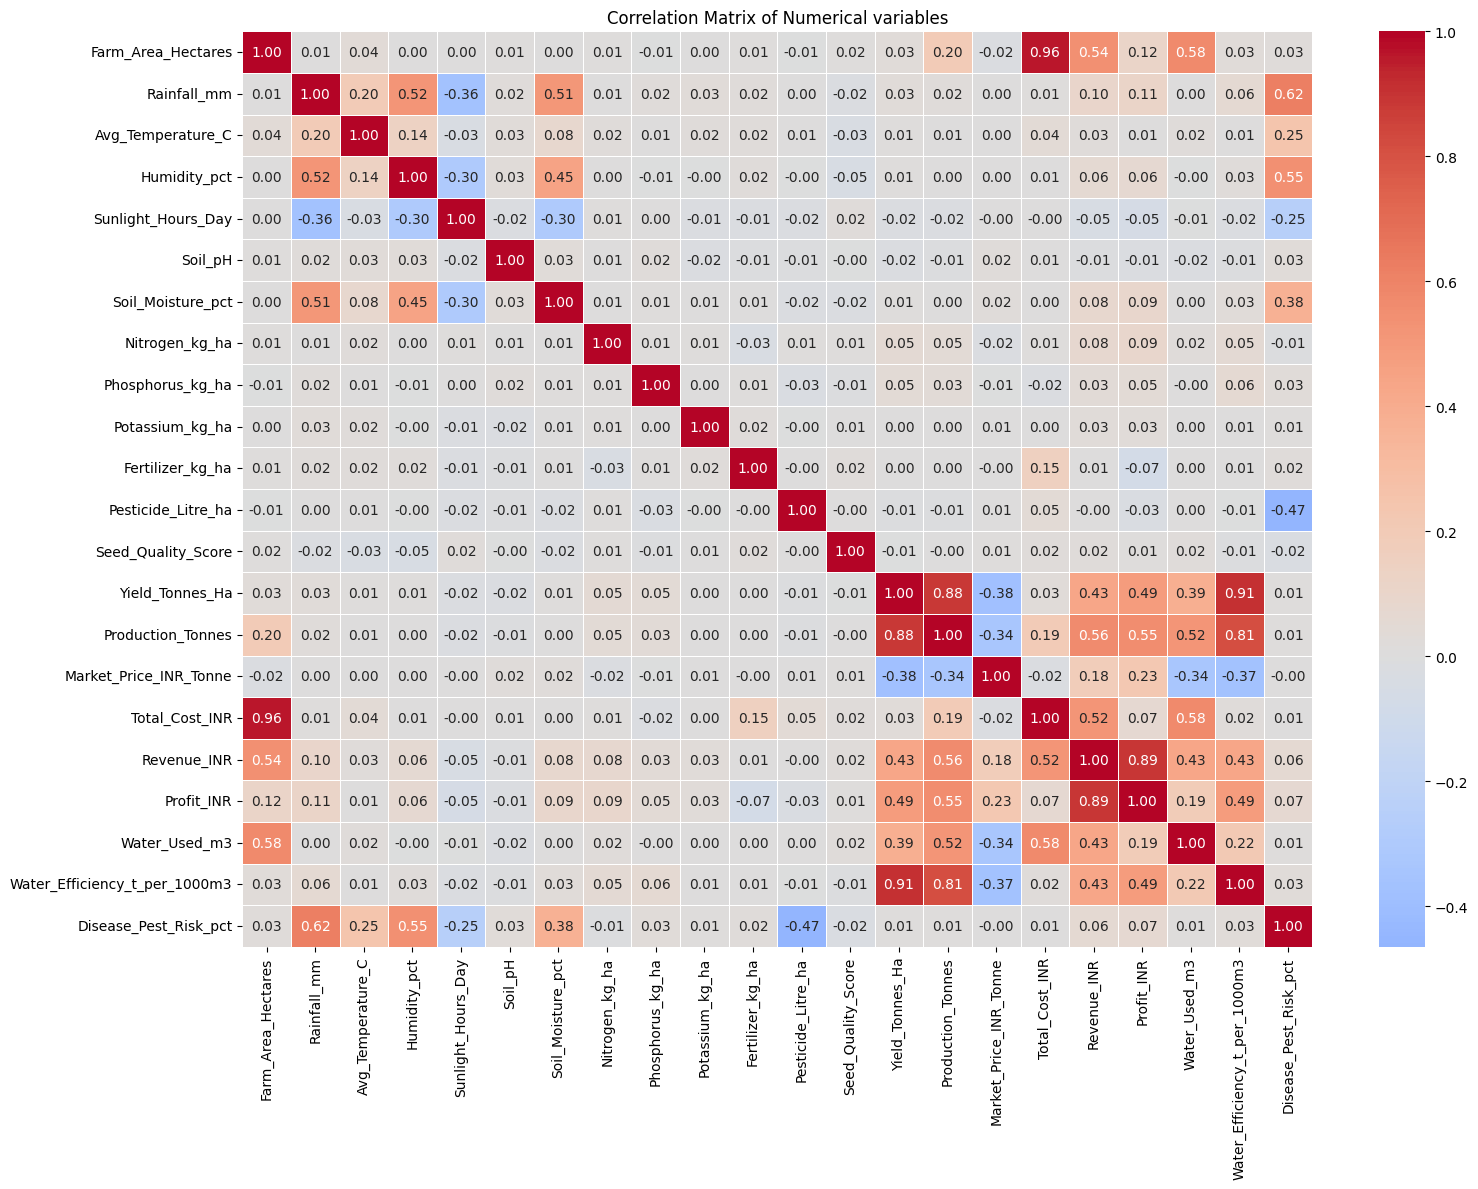

In [53]:
#Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr= df[numeric_columns].corr(numeric_only=True)
sns.heatmap(corr,annot=True, fmt=".2f", cmap="coolwarm",center=0,linewidths=0.5 )
plt.title("Correlation Matrix of Numerical variables")
plt.tight_layout()
plt.show()

**Observation:** Strong positive correlations: Farm Area vs Production (0.62), Rainfall vs Humidity (0.58) and Soil Moisture (0.51), Temperature vs Humidity (0.52). Strong negative correlation: Temperature vs Rainfall (-0.36) and Humidity (-0.30). Yield weakly correlates with Rainfall (0.10) and Profit (0.11). Profit shows weak correlation with most variables.

In [54]:
#General seasonal summary

season_metrics= df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round (2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89


Observation: Kharif has highest records (1779), yield (5.63), total production (82,387 tonnes), average profit (₹1.79L), and total profit (₹31.8 Cr). Rabi moderate (5.04 yield, ₹87,689 avg profit). Zaid lowest (4.64 yield, negative avg profit -₹24,805, total loss -₹1.47 Cr). Water usage highest in Zaid (6,420 m³), lowest in Rabi (5,847 m³).



In [55]:
#Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
            Average_Yield=("Yield_Tonnes_Ha", "mean"),
            Average_Profit=("Profit_INR", "mean"),
            Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.70       -64903.40                      2.17
       Wheat               2.25      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.29       731612.86                     27.92
       Maize               2.60       -89133.40                      5.46
       Rice                2.32       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.47       638572.50                      2.89
       Groundnut           1.23        10416.54                      2.90
       Cotton              1.20       107343.59                      1.94
       Pulses              0.88       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.29      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.20       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.96       -53925.34                      1.49
       Pulses              0.67      -139227.81                      1.95

**Observation:** Sugarcane dominates yields (53.46 Kharif, 43.29 Rabi, 38.42 Zaid) and profits (₹10L+ Kharif) across all seasons. Chilli shows high profit (₹9.5L Kharif) despite moderate yield (1.73). Most food grains (Wheat, Rice, Maize) show negative average profits, especially in Zaid. Water efficiency highest for Sugarcane (36.0 Kharif) and lowest for Cotton/Pulses.



# Key Insights

1. Kharif is the strongest-performing season.
Kharif has the highest average yield, total production, and total profit among the three seasons.

2. Zaid has the weakest economic performance.
Zaid has the lowest average yield and a negative total profit, indicating comparatively lower profitability in the dataset.

3. Water usage varies across seasons.
Zaid has the highest average water usage at approximately 6,419.89 m³, while Rabi has the lowest at approximately 5,846.99 m³.

4. Crop performance changes across seasons.
Sugarcane shows high yield and profitability across all three seasons, while several other crops show lower profitability, particularly in Zaid.

5. Irrigation methods show different performance levels.
Drip irrigation has the highest average yield and profit, while Rainfed farming has the highest average water-efficiency value.

6. Yield has a positive relationship with profit.
The correlation between yield and profit is approximately 0.49, indicating a moderate positive association between the two variables.

7. Environmental conditions vary across seasons.
Rainfall, temperature, humidity, and disease/pest risk differ between seasons and occur alongside differences in agricultural performance.

8. Seasonal differences can support agricultural planning.
The findings can help compare crop selection, irrigation practices, water usage, productivity, and profitability when planning agricultural activities for different seasons.


# Recommendations

1. Give greater attention to Kharif-season planning.
Kharif showed the highest average yield, total production, and total profit in the dataset. Therefore, agricultural planning can give greater attention to crop and resource allocation during Kharif. However, this finding is based on the available dataset and does not prove that Kharif will always be the most profitable season.

2. Carefully evaluate crop selection for Zaid season.
Zaid recorded the lowest average yield and a negative total profit. Therefore, farmers and planners should carefully evaluate crop choices and expected costs and returns before allocating resources to Zaid cultivation. The recommendation should be considered together with local conditions and market prices.

3. Consider water usage when planning seasonal activities.
Zaid had the highest average water usage, while also showing lower yield and profitability. Therefore, water requirements should be reviewed before seasonal crop planning, particularly for activities with high water consumption.

4. Consider suitable irrigation methods based on the observed performance.
Drip irrigation showed the highest average yield and average profit among the irrigation methods, while Rainfed farming showed the highest water-efficiency value. Therefore, irrigation methods can be compared based on both productivity and water efficiency rather than using only one measure. The dataset does not establish that irrigation method alone caused these differences.

5. Give attention to high-performing crop categories.
Sugarcane and Chilli showed relatively high average profitability across the seasons. Therefore, these crops can be considered during seasonal planning where their cultivation is suitable. Crop selection should not be based on profitability alone because the dataset does not include all external factors such as food-security requirements or future market conditions.

6. Monitor costs along with yield and revenue.
The analysis shows substantial variation in profit, with some farms making losses despite agricultural production. Therefore, seasonal planning should consider production costs together with expected yield and revenue rather than focusing only on physical productivity.

7. Improve monitoring of low-performing crop-season combinations.
Several crop-season combinations, particularly some combinations in Zaid, showed negative average profits. These combinations should be reviewed for their costs, yields, water usage, and market prices before future planning decisions are made.

8. Use data-based seasonal planning rather than relying on season alone.
The analysis shows that agricultural performance differs not only by season but also by crop, irrigation method, resource usage, and environmental conditions. Therefore, planning decisions should consider these factors together instead of assuming that one season or farming practice is always better.

# Conclusion

The analysis of the Seasonal Agriculture Performance dataset revealed clear differences in agricultural performance across Kharif, Rabi, and Zaid seasons. Kharif showed the strongest overall performance in terms of average yield, total production, and total profit, while Zaid showed lower average yield and negative overall profitability. Water usage also varied across seasons, with Zaid having the highest average water usage. Crop performance and irrigation methods showed noticeable differences in yield, profit, and water efficiency, while yield had a moderate positive relationship with profit and rainfall showed only a weak relationship with profit. The analysis is limited to the available dataset and identifies associations rather than proving cause-and-effect relationships. Overall, the findings can support data-driven seasonal agricultural planning by helping compare crop selection, profitability, water usage, irrigation practices, and environmental conditions, while future analysis can investigate specific regions and crop-season combinations in greater detail.

